# Sentiment Analysis with RoBERTa

## Task 1.2 — Transformer-Based Model

In this notebook, we implement a Transformer-based sentiment classifier using RoBERTa.

We train and evaluate the model on three different datasets:
- 1K Amazon Reviews
- 25K Amazon Reviews
- Video Game Reviews

Each dataset is processed and evaluated independently using the same pipeline.
This ensures a fair comparison across models in Task 1.3.

In [ ]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path

from transformers import AutoTokenizer, AutoModelForSequenceClassification

from utils import device_check
from transformer_utils import (
    build_tf_loaders,
    fit_tf,
    evaluate_tf,
    plot_confusion_matrix_tf,
)

## Setup

In [2]:
LOG_WANDB = True
NUM_WORKERS = 8
PIN_MEMORY = True
SEED = 1

MODEL_NAME = "roberta-base"
MAX_LENGTH = 128
BATCH_SIZE = 16
NUM_EPOCHS = 1

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = device_check()

SPLITS_DIR = Path("../data/splits")

PyTorch: 2.11.0+cu130 | Python: 3.11.15 | OS: Linux 5.15.0-168-generic
CUDA available: True
GPUs: 1 x NVIDIA GeForce RTX 2080 Ti (11.3 GB)
CUDA: 13.0 | cuDNN: 91900
Using cuda / NVIDIA GeForce RTX 2080 Ti


## Dataset 1 — 1K Amazon Reviews

In [3]:
train_df = pd.read_csv(SPLITS_DIR / "1k_train.csv")
val_df = pd.read_csv(SPLITS_DIR / "1k_val.csv")
test_df = pd.read_csv(SPLITS_DIR / "1k_test.csv")

text_col = "Sentence"
label_col = "Class"

NUM_LABELS = 2
NUM_CLASSES = 2

## Tokenizer and DataLoaders

RoBERTa uses the same Hugging Face pipeline style as BERT, so we tokenize the text and build DataLoaders from the pre-split CSV files.

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

loaders = build_tf_loaders(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    tokenizer=tokenizer,
    text_col=text_col,
    label_col=label_col,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

train_loader = loaders["train"]
val_loader = loaders["val"]
test_loader = loaders["test"]

## Model

We fine-tune a pre-trained RoBERTa model for binary sentiment classification.

In [5]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Training

The model is trained on the training split and validated after every epoch.
The best checkpoint is restored automatically based on validation loss.

In [6]:
history_1k = fit_tf(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    wandb_kwargs={"project": "roberta-1k", "name": "roberta-1k"},
    log=LOG_WANDB,
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: hamid-sabeti (d7047e-group12) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc
1/1 |     0.4479 |     78.40% |     0.2681 |     91.11%


Training Accuracy,▁
Training Loss,▁
Validation Accuracy,▁
Validation Loss,▁
Training Accuracy,78.39506
Training Loss,0.44792
Validation Accuracy,91.11111
Validation Loss,0.26813



Restored best weights (val loss 0.2681)


## Final Test Evaluation and Confusion Matrix

The final result is reported on the held-out test set for fair comparison with the other models.

[RoBERTa-1K] Test loss: 0.1979 | Test acc: 93.00%


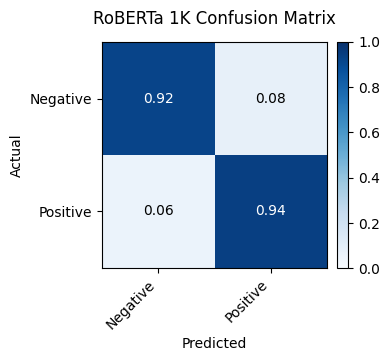

In [7]:
evaluate_tf(model, test_loader, criterion, label="RoBERTa-1K")

plot_confusion_matrix_tf(
    model,
    test_loader,
    NUM_CLASSES,
    ["Negative", "Positive"],
    "RoBERTa 1K Confusion Matrix",
    normalize=True,
)

## Dataset 2 — 25K Amazon Reviews

In [8]:
train_df = pd.read_csv(SPLITS_DIR / "25k_train.csv")
val_df = pd.read_csv(SPLITS_DIR / "25k_val.csv")
test_df = pd.read_csv(SPLITS_DIR / "25k_test.csv")

text_col = "Sentence"
label_col = "Class"

NUM_LABELS = 2
NUM_CLASSES = 2

## Tokenizer and DataLoaders

In [9]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

loaders = build_tf_loaders(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    tokenizer=tokenizer,
    text_col=text_col,
    label_col=label_col,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

train_loader = loaders["train"]
val_loader = loaders["val"]
test_loader = loaders["test"]

## Model

In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Training

In [11]:
history_25k = fit_tf(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    wandb_kwargs={"project": "roberta-25k", "name": "roberta-25k"},
    log=LOG_WANDB,
)

# Save the model
from pathlib import Path
import torch

SAVE_DIR = Path("Model_RoBERTa")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

model_save_path = SAVE_DIR / "roberta_25k.pt"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "model_name": MODEL_NAME,
        "num_labels": NUM_LABELS,
        "max_length": MAX_LENGTH,
    },
    model_save_path,
)

print(f"Model saved to: {model_save_path}")

Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc
1/1 |     0.2197 |     91.58% |     0.1636 |     94.40%


Training Accuracy,▁
Training Loss,▁
Validation Accuracy,▁
Validation Loss,▁
Training Accuracy,91.57531
Training Loss,0.21974
Validation Accuracy,94.4
Validation Loss,0.16362



Restored best weights (val loss 0.1636)
Model saved to: Model_RoBERTa/roberta_25k.pt


## Final Test Evaluation and Confusion Matrix

[RoBERTa-25K] Test loss: 0.1747 | Test acc: 94.04%


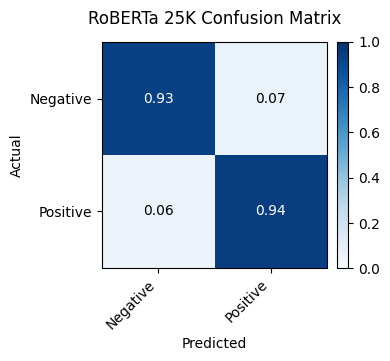

In [12]:
evaluate_tf(model, test_loader, criterion, label="RoBERTa-25K")

plot_confusion_matrix_tf(
    model,
    test_loader,
    NUM_CLASSES,
    ["Negative", "Positive"],
    "RoBERTa 25K Confusion Matrix",
    normalize=True,
)

## Dataset 3 — Video Game Reviews

In [13]:
train_df = pd.read_csv(SPLITS_DIR / "vg_train.csv")
val_df = pd.read_csv(SPLITS_DIR / "vg_val.csv")
test_df = pd.read_csv(SPLITS_DIR / "vg_test.csv")

text_col = "Sentence"
label_col = "Class"

# Convert labels from 1-5 → 0-4
train_df[label_col] = train_df[label_col].astype(int) - 1
val_df[label_col] = val_df[label_col].astype(int) - 1
test_df[label_col] = test_df[label_col].astype(int) - 1

NUM_LABELS = 5
NUM_CLASSES = 5

## Tokenizer and DataLoaders

In [14]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

loaders = build_tf_loaders(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    tokenizer=tokenizer,
    text_col=text_col,
    label_col=label_col,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

train_loader = loaders["train"]
val_loader = loaders["val"]
test_loader = loaders["test"]

## Model

In [15]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Training

In [16]:
history_vg = fit_tf(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    wandb_kwargs={"project": "roberta-vg", "name": "roberta-vg"},
    log=LOG_WANDB,
)

# Save the model
from pathlib import Path
import torch

SAVE_DIR = Path("Model_RoBERTa")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

model_save_path = SAVE_DIR / "roberta_vg.pt"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "model_name": MODEL_NAME,
        "num_labels": NUM_LABELS,
        "max_length": MAX_LENGTH,
    },
    model_save_path,
)

print(f"Model saved to: {model_save_path}")

Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc


Traceback (most recent call last):
  File "/root/D7047E/Lab1/src/utils_BERT.py", line 289, in fit_bert
    train_loss, train_acc = train_bert(model, train_loader, optimizer, criterion, scheduler)
                            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/root/D7047E/Lab1/src/utils_BERT.py", line 193, in train_bert
    running_loss += loss.item() * batch["labels"].size(0)
                    ^^^^^^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

## Final Test Evaluation and Confusion Matrix

In [ ]:
evaluate_tf(model, test_loader, criterion, label="RoBERTa-VG")

plot_confusion_matrix_tf(
    model,
    test_loader,
    NUM_CLASSES,
    ['★', '★★', '★★★', '★★★★', '★★★★★'],
    "RoBERTa Confusion Matrix - Video Game Reviews",
    normalize=True,
)